In [1]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from src.models import VAE
from src.data_preprocessing import (
    load_data_from_directory, 
    extract_and_normalize_peak_segments, 
    plot_random_segments,
    plot_random_files_from_directory,
    insert_synthetic_peaks)
from src.train import generate_synthetic_peaks
import torch.optim as optim
from src.train import train_vae

import pandas as pd
import os

%load_ext autoreload
%autoreload 2

## Load and preprocess data

In [2]:
fft_data = load_data_from_directory(directory='../data/processed/Final_Anomalous')
segment_length = 6
target_frequency = 150

normalized_peak_segments, minmax_stats = extract_and_normalize_peak_segments(
    fft_data, 
    segment_length=segment_length,
    target_frequency=target_frequency, 
    method='min-max'
)

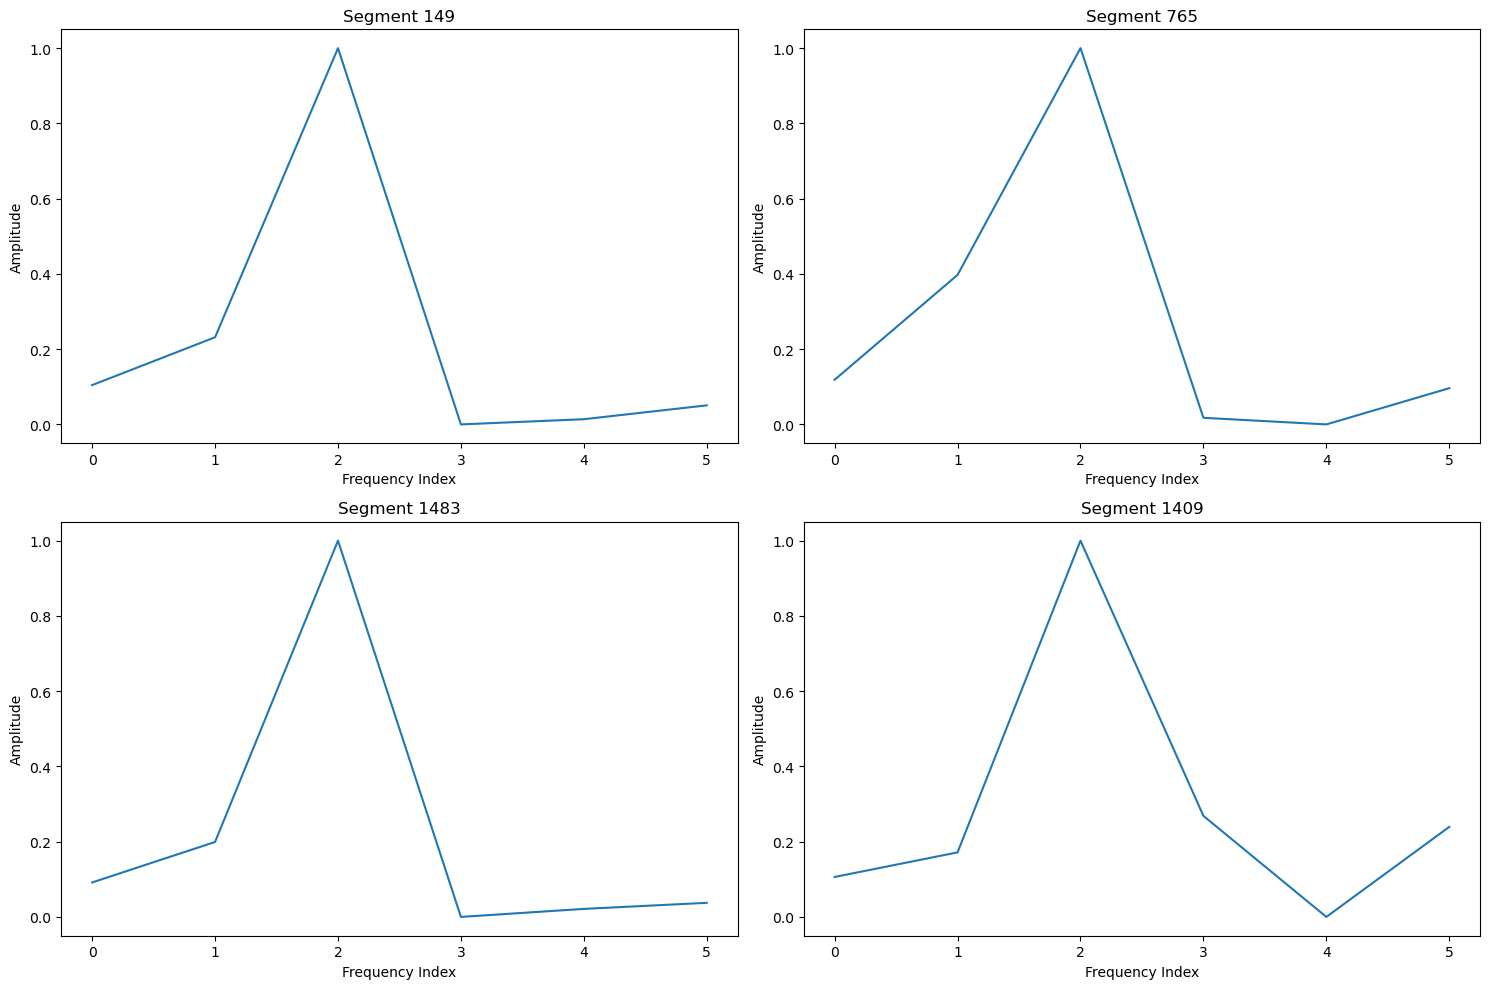

In [3]:
plot_random_segments(normalized_peak_segments, num_segments=4)

In [4]:
# Prepare data for training
data = torch.tensor(normalized_peak_segments, dtype=torch.float32)
input_shape = data.shape[1]
latent_dim = 10
batch_size = 32
data = data.view(-1, 1, input_shape)
dataset = TensorDataset(data)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [5]:
# Training parameters
epochs = 50
lr = 0.0001

# Initialize model and optimizer
vae = VAE(input_dim=input_shape, latent_dim=latent_dim)
optimizer = optim.Adam(vae.parameters(), lr=lr)

## Train the VAE

In [6]:
train_vae(vae, dataloader, optimizer, num_epochs=epochs)

Training:   0%|          | 0/2350 [00:00<?, ?batch/s]

Epoch 1/50, Avg Loss: 0.01915
Epoch 2/50, Avg Loss: 0.00427
Epoch 3/50, Avg Loss: 0.00386
Epoch 4/50, Avg Loss: 0.00363
Epoch 5/50, Avg Loss: 0.00355
Epoch 6/50, Avg Loss: 0.00336
Epoch 7/50, Avg Loss: 0.00326
Epoch 8/50, Avg Loss: 0.00316
Epoch 9/50, Avg Loss: 0.00315
Epoch 10/50, Avg Loss: 0.00303
Epoch 11/50, Avg Loss: 0.00299
Epoch 12/50, Avg Loss: 0.00297
Epoch 13/50, Avg Loss: 0.00287
Epoch 14/50, Avg Loss: 0.00283
Epoch 15/50, Avg Loss: 0.00280
Epoch 16/50, Avg Loss: 0.00274
Epoch 17/50, Avg Loss: 0.00270
Epoch 18/50, Avg Loss: 0.00267
Epoch 19/50, Avg Loss: 0.00265
Epoch 20/50, Avg Loss: 0.00267
Epoch 21/50, Avg Loss: 0.00264
Epoch 22/50, Avg Loss: 0.00258
Epoch 23/50, Avg Loss: 0.00257
Epoch 24/50, Avg Loss: 0.00257
Epoch 25/50, Avg Loss: 0.00253
Epoch 26/50, Avg Loss: 0.00257
Epoch 27/50, Avg Loss: 0.00253
Epoch 28/50, Avg Loss: 0.00252
Epoch 29/50, Avg Loss: 0.00253
Epoch 30/50, Avg Loss: 0.00251
Epoch 31/50, Avg Loss: 0.00250
Epoch 32/50, Avg Loss: 0.00248
Epoch 33/50, Avg 

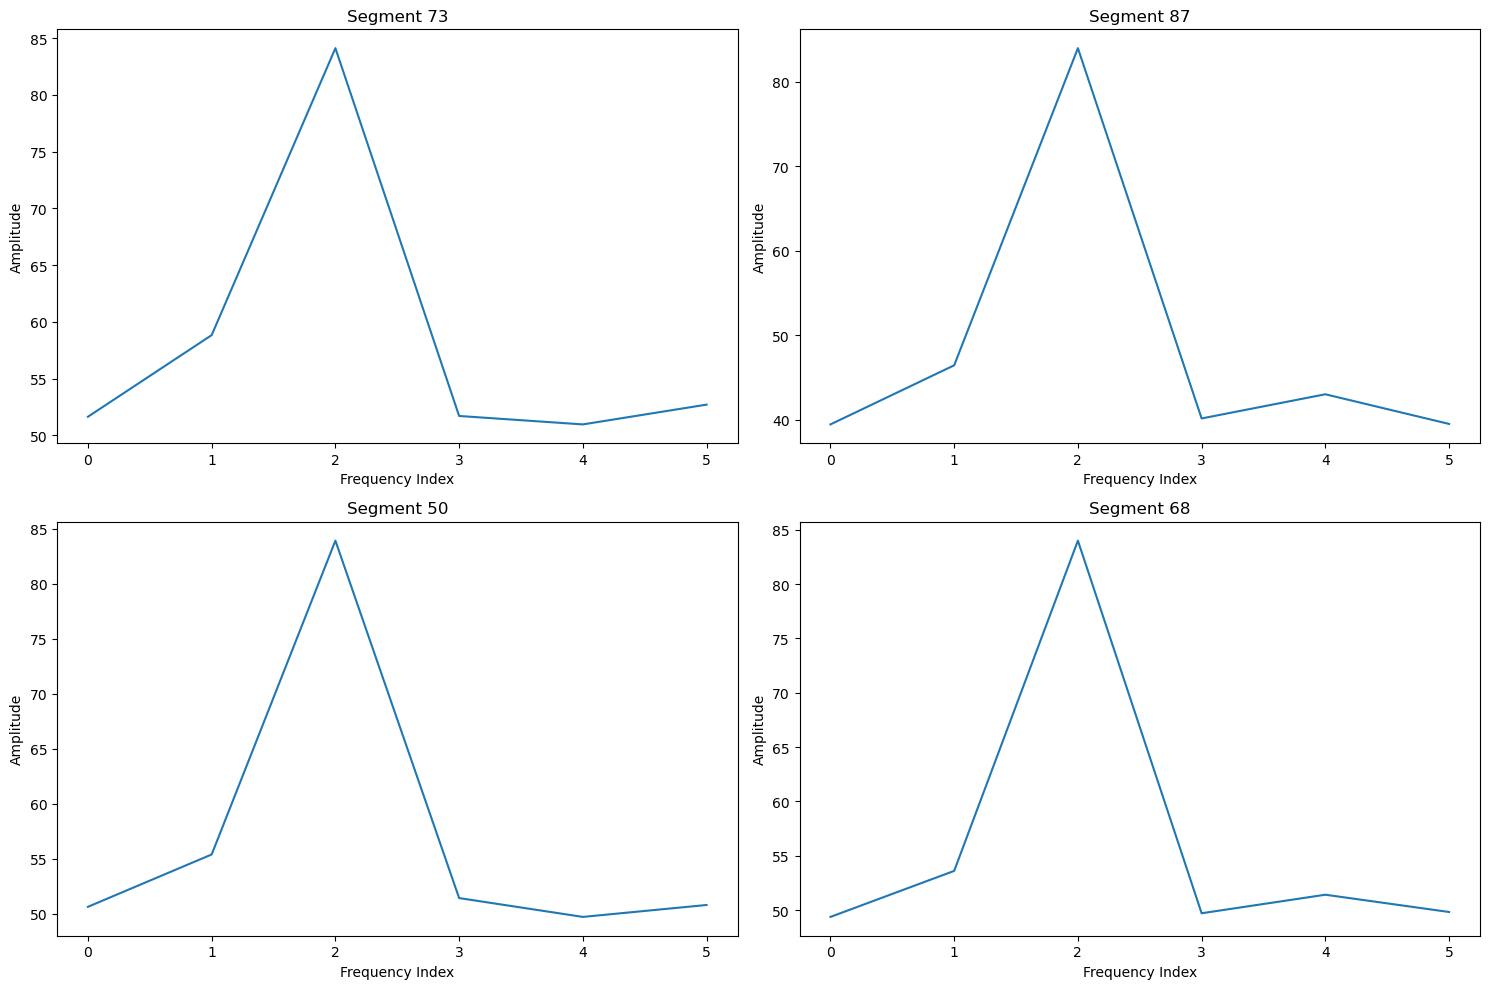

In [8]:
denormalized_generated_peaks = generate_synthetic_peaks(vae_model=vae, num_samples=100, latent_dim=latent_dim, 
                                                        segment_mins=minmax_stats[:, 0], segment_maxs=minmax_stats[:, 1])
plot_random_segments(denormalized_generated_peaks, num_segments=4)

## VAE Synthetic Peak Generation

In [9]:
candidates_df = load_data_from_directory(directory='../data/processed/Candidates_for_Augmentation')

In [10]:
# Insert Synthetic Peaks into Normal Data
anomalous_data = insert_synthetic_peaks(normal_data=candidates_df, 
                                        synthetic_peaks=denormalized_generated_peaks, 
                                        target_frequency=150,
                                        segment_length=6)


# Save the Data
folder_path = '../data/processed/Final_Synthetic'
os.makedirs(folder_path, exist_ok=True)

for i, data in enumerate(anomalous_data):
    df = pd.DataFrame(data, columns=["Data"])
    df.to_csv(os.path.join(folder_path, f'Window_{i}.csv'), index=False)

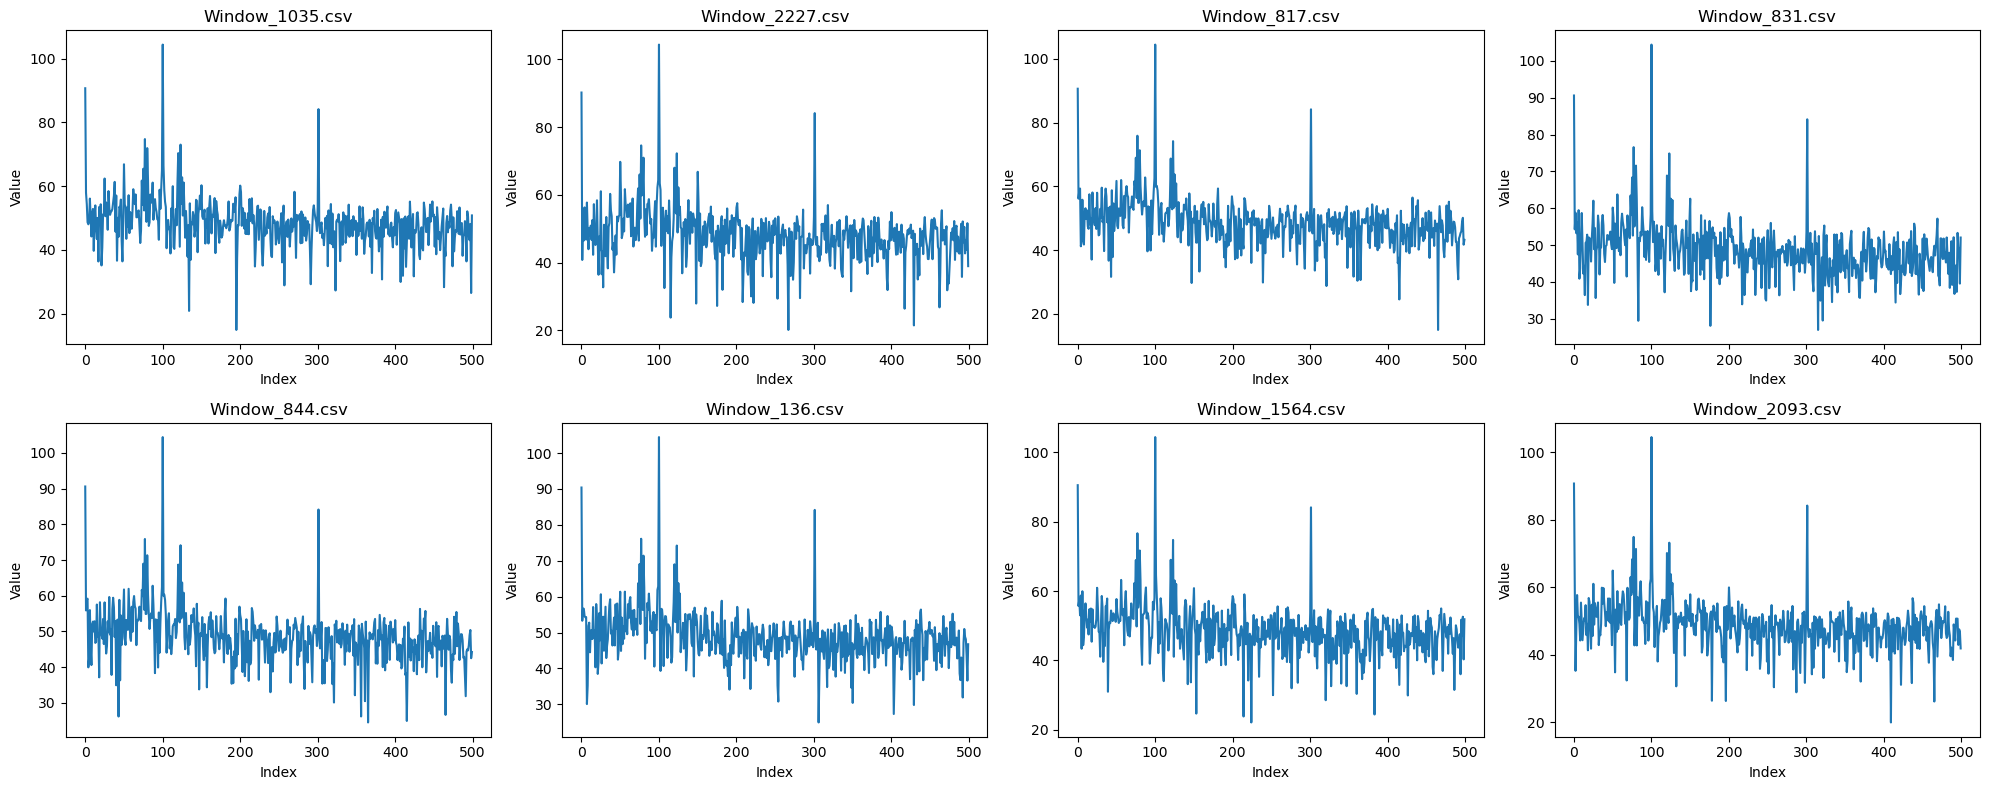

In [11]:
plot_random_files_from_directory(directory='../data/processed/Final_Synthetic', 
                                 num_files=8)